In [1]:
#cell1
import pandas as pd
import numpy as np
import json
import os
from datetime import datetime

os.chdir('C:/Project(CSE_155)/retail-digital-twin')

# Load the processed data we created in Module 1
user_behavior = pd.read_csv('datasets/processed/user_behavior.csv')

print(f"Loaded {len(user_behavior):,} customer profiles")
print(user_behavior.head())
print(user_behavior.columns.tolist())

Loaded 1,407,580 customer profiles
   visitorid  addtocart  transaction  view  engagement_score
0          0          0            0     3                 3
1          1          0            0     1                 1
2          2          0            0     8                 8
3          3          0            0     1                 1
4          4          0            0     1                 1
['visitorid', 'addtocart', 'transaction', 'view', 'engagement_score']


In [3]:
#cell2
import sys
sys.path.append('C:/Project(CSE_155)/retail-digital-twin')

from backend.core.digital_twin_engine import DigitalTwinEngine

# Initialize the engine with our processed data
engine = DigitalTwinEngine(user_behavior)

# Build all 1.4M Digital Twin profiles
twins = engine.build_twins()

print(twins.shape)
print(twins.columns.tolist())

Engine initialized with 1,407,580 customer records

🚀 Building Digital Twin profiles...
  ✓ Feature engineering complete
  ✓ Percentile rankings computed
  ✓ Engagement levels assigned
  ✓ Customer segments assigned
  ✓ Funnel positions assigned
  ✓ Purchase intent scores computed
  ✓ CLV tiers assigned
  ✓ ROI potential assigned
  ✓ Behavior types assigned
✅ 1,407,580 Digital Twin profiles generated
(1407580, 20)
['visitorid', 'total_addtocarts', 'total_purchases', 'total_views', 'engagement_score', 'total_events', 'view_to_cart_rate', 'cart_to_purchase_rate', 'view_to_purchase_rate', 'is_buyer', 'is_high_value', 'engagement_percentile', 'purchase_percentile', 'engagement_level', 'customer_segment', 'funnel_position', 'purchase_intent_score', 'clv_tier', 'roi_potential', 'behavior_type']


In [4]:
engine.save_twins('datasets/processed/digital_twins.csv')
print("Done.")

💾 Saved to datasets/processed/digital_twins.csv
Done.


In [5]:
# Cell 4 — View a Single Customer's Digital Twin
#Look at the most engaged customer
twin = engine.get_twin(1150086)

print("=" * 50)
print(f"DIGITAL TWIN — Customer #{twin['visitorid']}")
print("=" * 50)
print(f"  Total Views:            {twin['total_views']}")
print(f"  Add to Carts:           {twin['total_addtocarts']}")
print(f"  Purchases:              {twin['total_purchases']}")
print(f"  Engagement Score:       {twin['engagement_score']}")
print(f"  Engagement Level:       {twin['engagement_level']}")
print(f"  Engagement Percentile:  {twin['engagement_percentile']}%")
print(f"  Customer Segment:       {twin['customer_segment']}")
print(f"  Funnel Position:        {twin['funnel_position']}")
print(f"  Purchase Intent Score:  {twin['purchase_intent_score']}")
print(f"  Behavior Type:          {twin['behavior_type']}")
print(f"  CLV Tier:               {twin['clv_tier']}")
print(f"  ROI Potential:          {twin['roi_potential']}")
print(f"  Is Buyer:               {twin['is_buyer']}")
print(f"  Is High Value:          {twin['is_high_value']}")
print("=" * 50)

DIGITAL TWIN — Customer #1150086
  Total Views:            6479
  Add to Carts:           719
  Purchases:              559
  Engagement Score:       11431
  Engagement Level:       POWER
  Engagement Percentile:  100.0%
  Customer Segment:       Power Buyer
  Funnel Position:        PURCHASE
  Purchase Intent Score:  0.7443
  Behavior Type:          IMPULSE
  CLV Tier:               PREMIUM
  ROI Potential:          HIGH
  Is Buyer:               True
  Is High Value:          True


=== CUSTOMER SEGMENT BREAKDOWN ===

                    count  avg_engagement  avg_purchases  avg_intent
customer_segment                                                    
Passive Visitor   1325326           1.398          0.000       0.000
Window Shopper      43389          11.106          0.000       0.000
Engaged Browser     27146          10.120          0.000       0.106
Buyer               11581          21.239          1.379       0.533
Power Buyer           138         938.225         47.043       0.537


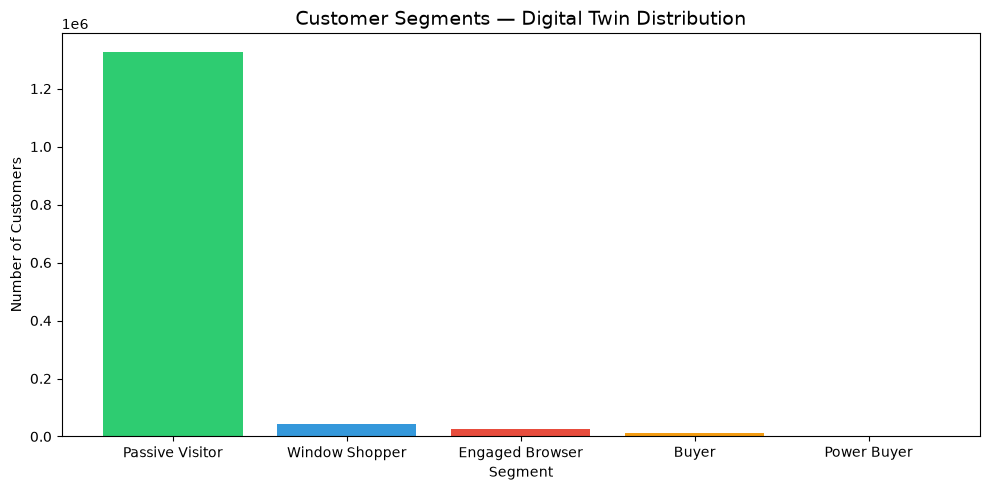

In [6]:
#Cell 5 — Segment Distribution

print("=== CUSTOMER SEGMENT BREAKDOWN ===\n")
summary = engine.get_segment_summary()
print(summary)

# Plot
import matplotlib.pyplot as plt

segment_counts = twins['customer_segment'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(segment_counts.index, segment_counts.values,
        color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'])
plt.title('Customer Segments — Digital Twin Distribution', fontsize=14)
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
plt.tight_layout()
plt.savefig('research/segment_distribution.png')
plt.show()

In [7]:
#Cell 6 — Intelligence Summary

print("=" * 50)
print("DIGITAL TWIN ENGINE — INTELLIGENCE REPORT")
print("=" * 50)
print(f"Total Twins Generated:     {len(twins):,}")
print(f"\n--- Engagement Levels ---")
print(twins['engagement_level'].value_counts().to_string())
print(f"\n--- Funnel Positions ---")
print(twins['funnel_position'].value_counts().to_string())
print(f"\n--- CLV Tiers ---")
print(twins['clv_tier'].value_counts().to_string())
print(f"\n--- Behavior Types ---")
print(twins['behavior_type'].value_counts().to_string())
print(f"\n--- ROI Potential ---")
print(twins['roi_potential'].value_counts().to_string())
print(f"\n--- Key Stats ---")
print(f"Buyers:                    {twins['is_buyer'].sum():,}")
print(f"High Value Customers:      {twins['is_high_value'].sum():,}")
print(f"Avg Purchase Intent Score: {twins['purchase_intent_score'].mean():.4f}")
print("=" * 50)
print("✅ Ready for Module 3: Engagement Prediction Pipeline")

DIGITAL TWIN ENGINE — INTELLIGENCE REPORT
Total Twins Generated:     1,407,580

--- Engagement Levels ---
engagement_level
LOW       1337813
MEDIUM      61269
HIGH         7949
POWER         549

--- Funnel Positions ---
funnel_position
AWARENESS        1271384
CONSIDERATION      97331
INTENT             27146
PURCHASE           11719

--- CLV Tiers ---
clv_tier
LOW        998953
MEDIUM     274968
HIGH       133501
PREMIUM       158

--- Behavior Types ---
behavior_type
CASUAL        1371142
RESEARCHER      22967
IMPULSE          8980
EXPLORER         4227
LOYAL             264

--- ROI Potential ---
roi_potential
NOT WORTH    1198670
LOW           171188
MEDIUM         35694
HIGH            2028

--- Key Stats ---
Buyers:                    11,719
High Value Customers:      93,412
Avg Purchase Intent Score: 0.0065
✅ Ready for Module 3: Engagement Prediction Pipeline
